<img src=".\assets\on_black.png" alt="netective logo" style="width:18%;">

Compare networks based on their structure and performance statistics.
<br><br>
## Python Module Tutorial

Explore the main features of the Python module for network comparison.

- For a tutorial on the command-line interface, refer to [this link]().
- Access the web service for small jobs [here]().

---

The module consists of two submodules: `structure` and `stats`, each with module-level functions for convenient usage.

In this guide, we'll cover the following topics:

1. **Module-level functions** 📦
2. **Submodule `structure`** 🕸️📐
   Useful for comparing networks with different node IDs.

3. **Submodule `stats`** 📊
   Requires networks to share node IDs. Useful for comparing inferred networks against a gold standard.

<br>

Make sure to have netective installed:

In [1]:
# %pip install netective

<br>

### Module-level functions 📦

The module-level functions empower users, even those with basic Python proficiency, to seamlessly employ netective to characterize network structure, compare networks, and assess inference performance.

In [1]:
# Third-party imports
import networkx as nx
from scipy.stats import spearmanr

#### characterize network structure


[get_props] [WARNING] [The network or the normalization method has changed. Computing its properties...]


(<Figure size 200x780 with 1 Axes>, <Figure size 1200x750 with 11 Axes>)

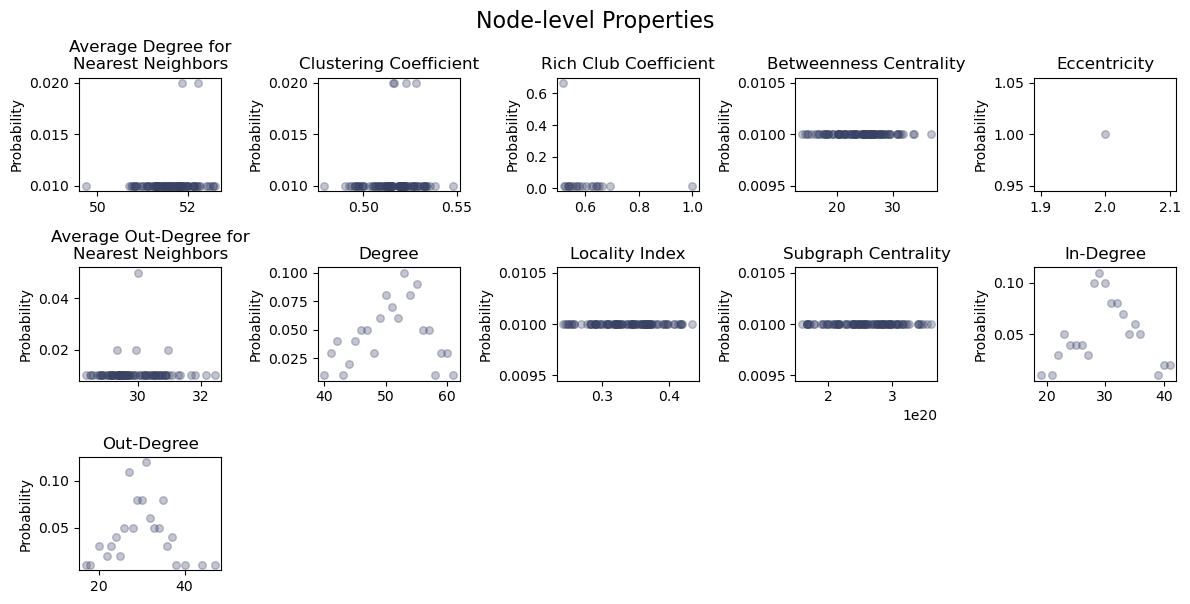

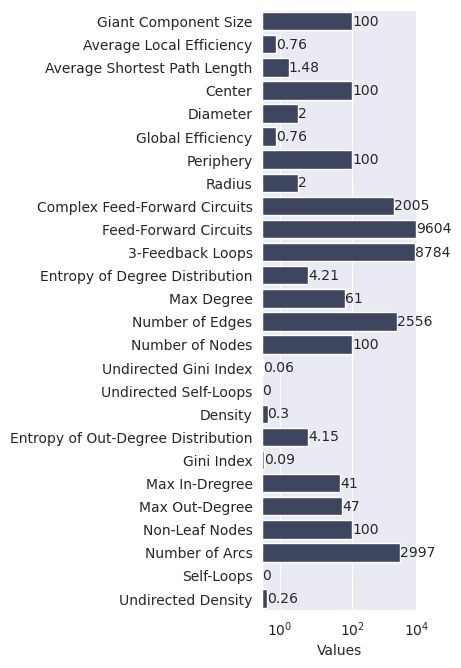

In [2]:
from netective import characterize_network

# Let's create a random network to characterize
G = nx.erdos_renyi_graph(100, 0.3, directed=True)

# Characterize the network is as simple as calling the function with the network and an identifier as arguments
characterize_network(G, "my_network")

Networks may have different size. Use the norm parameter to get normalized values.


[get_props] [WARNING] [The network or the normalization method has changed. Computing its properties...]
[INFO] Properties used for analysis (based on selected_props): 
[INFO] Average Degree for Nearest Neighbors
[INFO] Average Local Efficiency
[INFO] Average Out-Degree for Nearest Neighbors
[INFO] Average Shortest Path Length
[INFO] Betweenness Centrality
[INFO] Center
[INFO] Clustering Coefficient
[INFO] Complex Feed-Forward Circuits
[INFO] Degree
[INFO] Density
[INFO] Diameter
[INFO] Eccentricity
[INFO] Entropy of Degree Distribution
[INFO] Entropy of Out-Degree Distribution
[INFO] Feed-Forward Circuits
[INFO] 3-Feedback Loops
[INFO] Giant Component Size
[INFO] Gini Index
[INFO] Global Efficiency
[INFO] In-Degree
[INFO] Locality Index
[INFO] Max Degree
[INFO] Max In-Dregree
[INFO] Max Out-Degree
[INFO] Non-Leaf Nodes
[INFO] Number of Arcs
[INFO] Number of Edges
[INFO] Number of Nodes
[INFO] Out-Degree
[INFO] Periphery
[INFO] Radius
[INFO] Rich Club Coefficient
[INFO] Self-Loops
[IN

(<Figure size 200x690 with 1 Axes>, <Figure size 1200x600 with 9 Axes>)

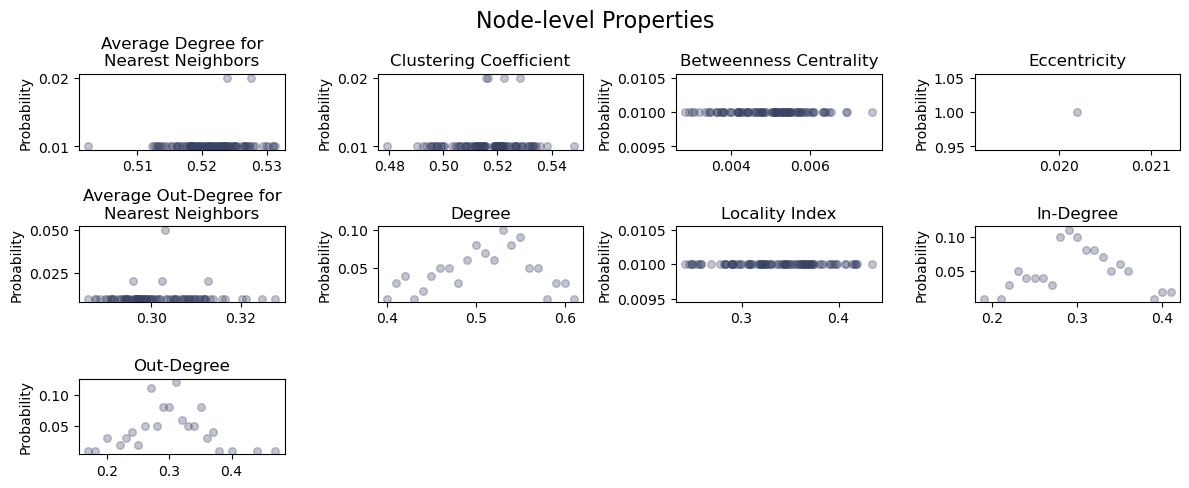

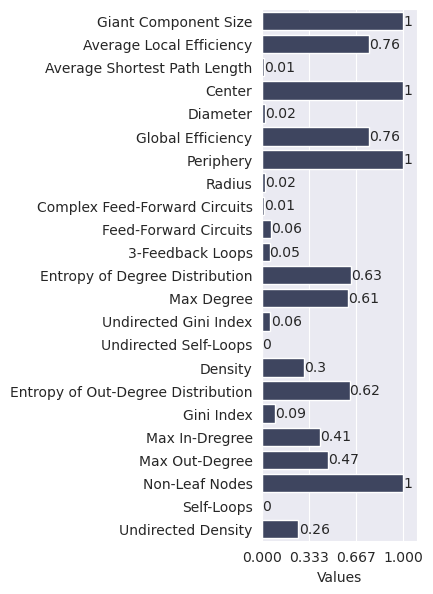

In [3]:
# norm parameter allows you to normalize data using different approaches depending on the nature of the networks analyzed
# default is None for no normalization, uses raw data
# norm = "network" normalize the network by the network size

characterize_network(G, "my_network", norm="network", verbose='info')


[get_props] [WARNING] [The network or the normalization method has changed. Computing its properties...]

[_normalize_props] [WARNING] [Properties excluded from analysis due to lack of normalization:]

[_normalize_props] [WARNING] [Rich Club Coefficient]

[_normalize_props] [WARNING] [Number of Edges]

[_normalize_props] [WARNING] [Number of Nodes]

[_normalize_props] [WARNING] [Subgraph Centrality]

[_normalize_props] [WARNING] [Number of Arcs]


(<Figure size 200x690 with 1 Axes>, <Figure size 1200x600 with 9 Axes>)

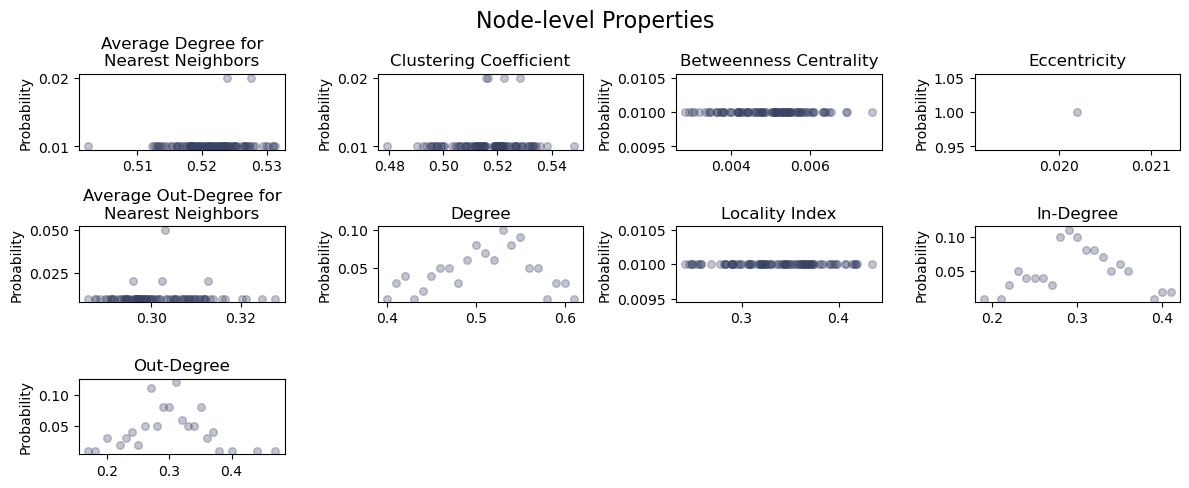

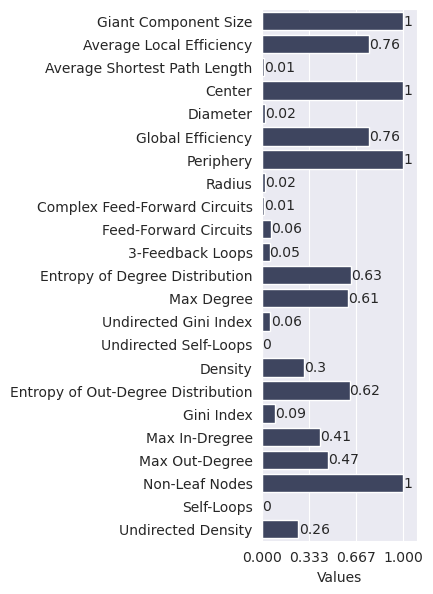

In [4]:
# norm = "biological" normalize the network by the number of regulators

characterize_network(G, "my_network", norm="biological")

Netective v1.0 uses a total of 28 network properties for characterization and comparison:

`Node-Level Properties`
- In-Degree (InDegre)
- Out-Degree (OutDegre)
- Locality Index (LocalityIndex)
- Subgraph Centrality (SubgraphCentrality)
- Average Degree of Nearest Neighbors using out-out degree (AverageOutDegreeNearestNeighbors)
- Average Degree of Nearest Neighbors using undirected network (AverageDegreeNearestNeighbors)
- Clustering Coefficient (ClusteringCoefficient)
- Rich Club Coefficient (RichClub)
- Betweenness Centrality (BetweennessCentrality)
- Eccentricity (Eccentricity)

`Network-Level Properties`
- Entropy of Degree Distribution (EntropyPKout)
- Gini Index (GiniIndex)
- Max In-Degree (MaxInDegree)
- Max Out-Degree (MaxOutDegree)
- Regulators (Regulators)
- Self-Regulations (SelfRegulations)
- Density (Density)
- Complex Feed-Forward Circuits (ComplexFeedForwardCircuits)
- 3-Feedback Loops (FeedbakcLoops_3)
- Average Clustering Coefficient (AverageClusteringCoefficient)
- Gene % in the Giant Component (GenesintheGiantComponent)
- Average Local Efficiency (AverageLocalEfficiency)
- Average Shortest Path Length (AverageShortestPathLength)
- Center (Center)
- Diameter (Diameter)
- Global Efficiency (GlobalEfficiency)
- Periphery (Periphery)
- Radius (Radius)

***correct spelling for list in parenthesis***

characterize_network function allows you to provide a list of chosen properties to use if you do not want to use the complete set, using the parameter selected_props ***default is all properties***


[get_props] [WARNING] [The network or the normalization method has changed. Computing its properties...]



[_normalize_props] [WARNING] [Properties excluded from analysis due to lack of normalization:]


(<Figure size 200x120 with 1 Axes>, None)

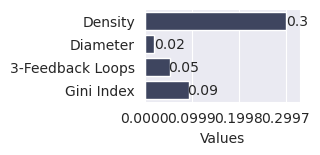

In [5]:
# using the same network

my_properties = ['Gini Index', 'Density', 'Diameter', 'LocalityIndex', 'InDegree', 'RichClub', '3-Feedback Loops']

characterize_network(G, "my_network", norm="network", selected_props= my_properties)

#### compare networks based on their structure

[INFO] Properties used for analysis (based on selected_props): 
[INFO] Average Degree for Nearest Neighbors
[INFO] Average Local Efficiency
[INFO] Average Out-Degree for Nearest Neighbors
[INFO] Average Shortest Path Length
[INFO] Betweenness Centrality
[INFO] Center
[INFO] Clustering Coefficient
[INFO] Complex Feed-Forward Circuits
[INFO] Degree
[INFO] Density
[INFO] Diameter
[INFO] Eccentricity
[INFO] Entropy of Degree Distribution
[INFO] Entropy of Out-Degree Distribution
[INFO] Feed-Forward Circuits
[INFO] 3-Feedback Loops
[INFO] Giant Component Size
[INFO] Gini Index
[INFO] Global Efficiency
[INFO] In-Degree
[INFO] Locality Index
[INFO] Max Degree
[INFO] Max In-Dregree
[INFO] Max Out-Degree
[INFO] Non-Leaf Nodes
[INFO] Number of Arcs
[INFO] Number of Edges
[INFO] Number of Nodes
[INFO] Out-Degree
[INFO] Periphery
[INFO] Radius
[INFO] Rich Club Coefficient
[INFO] Self-Loops
[INFO] Subgraph Centrality
[INFO] Undirected Density
[INFO] Undirected Gini Index
[INFO] Undirected Self-Loop

  0%|          | 0/2 [00:00<?, ?it/s]

[INFO] Running my_network_G...
[INFO] Running my_network_H...

[run_parallel] [WARNING] [Finilized: my_network_H]


 50%|█████     | 1/2 [00:02<00:02,  2.54s/it]


[run_parallel] [WARNING] [Finilized: my_network_G]


...


[run_parallel] [WARNING] [Finilized: ER_model_19_my_network_H]

[run_parallel] [WARNING] [Finilized: ER_model_15_my_network_H]

[run_parallel] [WARNING] [Finilized: ER_model_25_my_network_H]

[run_parallel] [WARNING] [Finilized: ER_model_21_my_network_H]

[run_parallel] [WARNING] [Finilized: ER_model_20_my_network_H]

[run_parallel] [WARNING] [Finilized: ER_model_27_my_network_H]


 80%|████████  | 12/15 [00:04<00:00,  4.41it/s]


[run_parallel] [WARNING] [Finilized: ER_model_28_my_network_H]

[run_parallel] [WARNING] [Finilized: ER_model_24_my_network_H]

[run_parallel] [WARNING] [Finilized: ER_model_29_my_network_H]


100%|██████████| 15/15 [00:05<00:00,  2.92it/s]


[INFO] Creating symmetric heatmap...


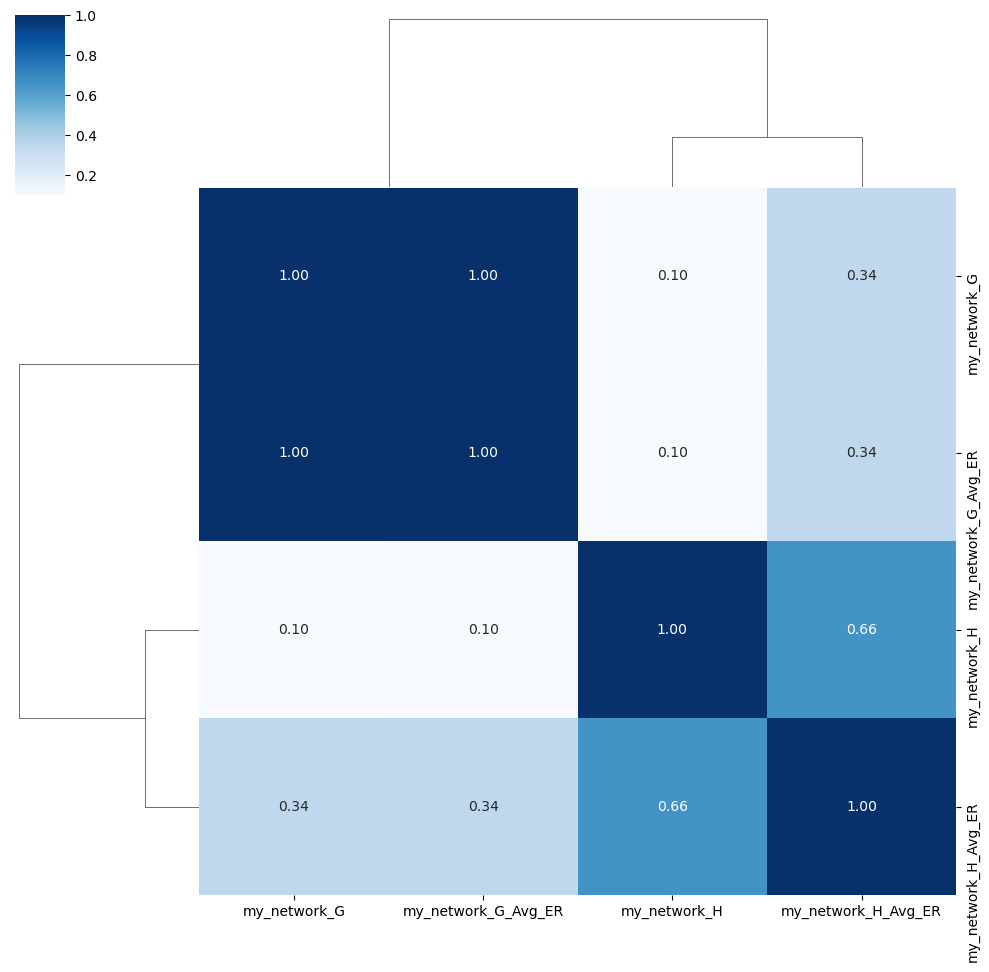

In [6]:
from netective import compare_structure
import networkx as nx

# Let's create a random network to characterize
G = nx.erdos_renyi_graph(100, 0.3, directed=True)
# Let's create a second network to compare to the first one.
H = nx.path_graph(50, create_using=nx.DiGraph)

# Comparing both networks is as simple as calling the function with a dictionary of networks.
networks = {"my_network_G": G, "my_network_H": H}
compare_structure(networks, return_prop_dicts=False, erdos_renyi=30, verbose='info', norm="network");

[INFO] Properties used for analysis (based on selected_props): 
[INFO] Average Degree for Nearest Neighbors
[INFO] Average Local Efficiency
[INFO] Average Out-Degree for Nearest Neighbors
[INFO] Average Shortest Path Length
[INFO] Betweenness Centrality
[INFO] Center
[INFO] Clustering Coefficient
[INFO] Complex Feed-Forward Circuits
[INFO] Degree
[INFO] Density
[INFO] Diameter
[INFO] Eccentricity
[INFO] Entropy of Degree Distribution
[INFO] Entropy of Out-Degree Distribution
[INFO] Feed-Forward Circuits
[INFO] 3-Feedback Loops
[INFO] Giant Component Size
[INFO] Gini Index
[INFO] Global Efficiency
[INFO] In-Degree
[INFO] Locality Index
[INFO] Max Degree
[INFO] Max In-Dregree
[INFO] Max Out-Degree
[INFO] Non-Leaf Nodes
[INFO] Number of Arcs
[INFO] Number of Edges
[INFO] Number of Nodes
[INFO] Out-Degree
[INFO] Periphery
[INFO] Radius
[INFO] Rich Club Coefficient
[INFO] Self-Loops
[INFO] Subgraph Centrality
[INFO] Undirected Density
[INFO] Undirected Gini Index


[INFO] Undirected Self-Loops
[INFO] 

[compare_structure] [WARNING] [Getting optimal number of workers based on available memory and inputed networks sizes...]


  0%|          | 0/3 [00:00<?, ?it/s]

[INFO] Running my_network_G...
[INFO] Running my_network_H...
[INFO] Running my_network_F...

[run_parallel] [WARNING] [Finilized: my_network_F]


 33%|███▎      | 1/3 [00:02<00:04,  2.20s/it]


[run_parallel] [WARNING] [Finilized: my_network_H]

[run_parallel] [WARNING] [Finilized: my_network_G]


100%|██████████| 3/3 [00:03<00:00,  1.26s/it]

[INFO] Creating symmetric heatmap...


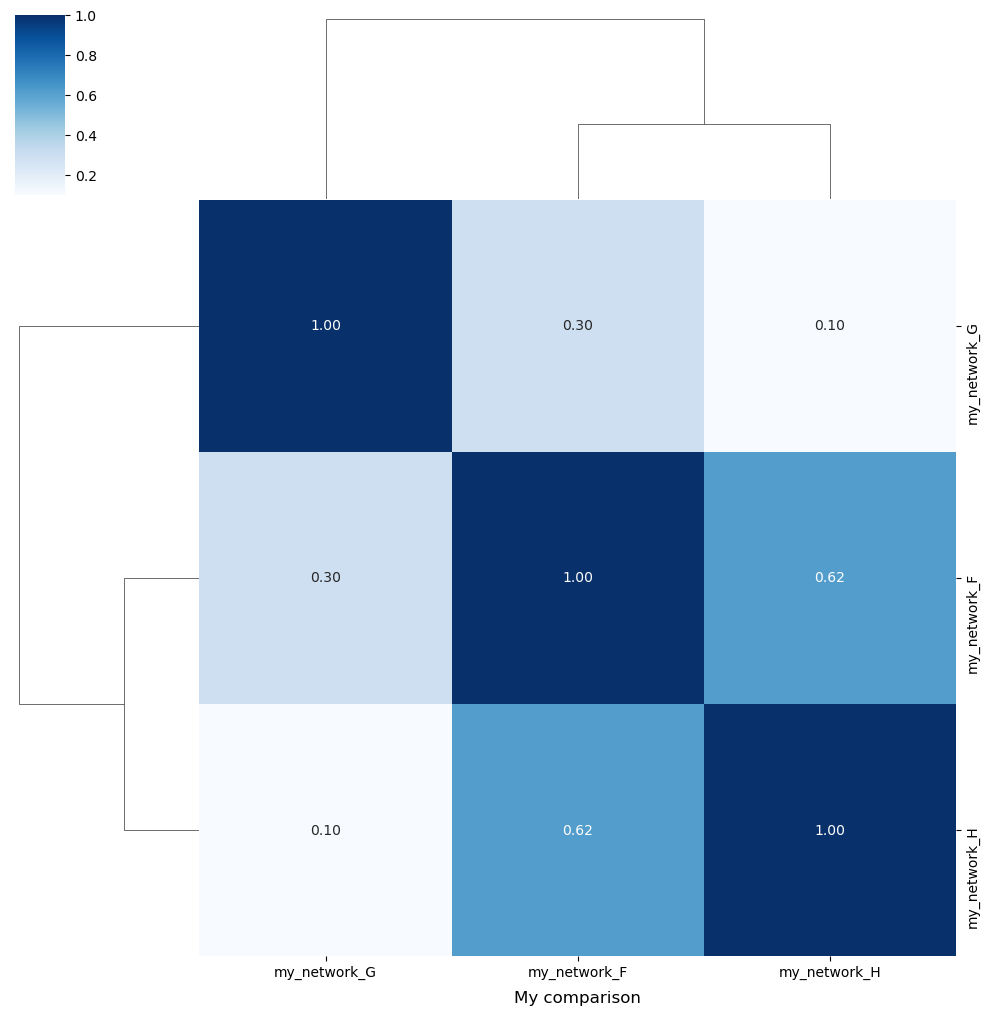

In [7]:
from netective import compare_structure
import networkx as nx

# Let's create a random network to characterize
G = nx.erdos_renyi_graph(100, 0.3, directed=True)
F = nx.erdos_renyi_graph(50, 50/50**2, directed=True)
# Let's create a second network to compare to the first one.
H = nx.path_graph(50, create_using=nx.DiGraph)

# Comparing both networks is as simple as calling the function with a dictionary of networks.
networks = {"my_network_G": G, "my_network_H": H, "my_network_F": F}
compare_structure(networks, return_prop_dicts=False, verbose='info', norm="network", title="My comparison"); # note that you can set a title that will be displayed at the bottom of the heatmap

In [8]:
tuple(dict.fromkeys([3,2,1,2,2,3]))

(3, 2, 1)


[compare_structure] [WARNING] [Multiprocessing enabled in 2 out of 15 usable threads detected]

[compare_structure] [WARNING] [Starting topological characterization of networks: ['my_network_G', 'my_network_H']...]


  0%|          | 0/2 [00:00<?, ?it/s]


[run_parallel] [WARNING] [Finilized: my_network_H]


 50%|█████     | 1/2 [00:01<00:01,  1.93s/it]


[run_parallel] [WARNING] [Finilized: my_network_G]


100%|██████████| 2/2 [00:03<00:00,  1.76s/it]


[compare_structure] [WARNING] [Starting topological characterization of networks: ['my_network_F']...]



  0%|          | 0/1 [00:00<?, ?it/s]


[run_parallel] [WARNING] [Finilized: my_network_F]


100%|██████████| 1/1 [00:02<00:00,  2.26s/it]


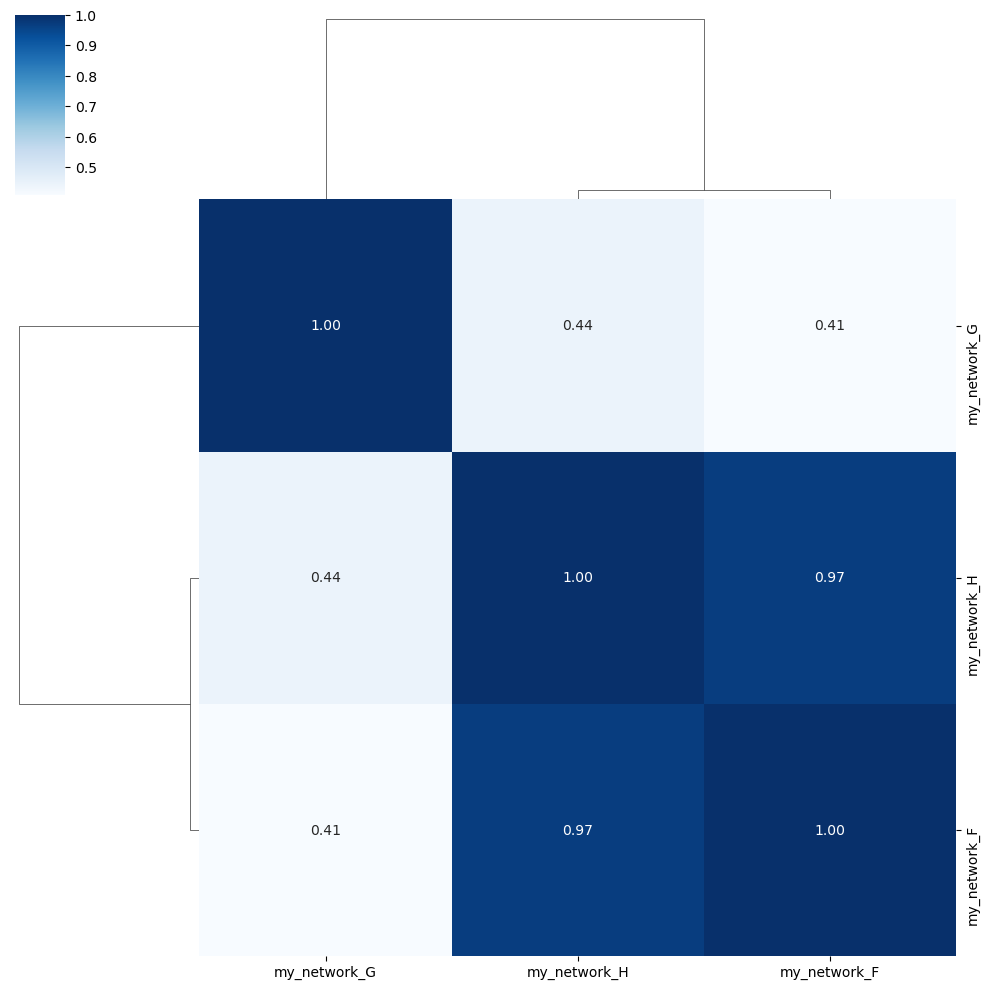

In [9]:
# pearsonr is used by default to compare networks. Other methods are available using the parameter association_metric.
# compare_structure runs in parallel by default. Use workers to specify the number of processes to run in parallel.
# TODO definir bien cómo es la comparación de redes

compare_structure(networks, workers=2, association_metric=spearmanr);


[compare_structure] [WARNING] [Multiprocessing enabled in 2 out of 15 usable threads detected]

[compare_structure] [WARNING] [Starting topological characterization of networks: ['my_network_G', 'my_network_H']...]


  0%|          | 0/2 [00:00<?, ?it/s]


[run_parallel] [WARNING] [Finilized: my_network_H]


 50%|█████     | 1/2 [00:01<00:01,  1.80s/it]


[run_parallel] [WARNING] [Finilized: my_network_G]


...


[run_parallel] [WARNING] [Finilized: my_network_F]


100%|██████████| 1/1 [00:02<00:00,  2.09s/it]

c:\Users\jmere\.conda\envs\pyfl38\lib\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


[dataviz] [create_symmetric_heatmap] [CRITICAL] [For one or more networks the properties array is constant. Correlation coefficient is not defined. Maybe adding more properties fro analysis...]


ValueError: For one or more networks the properties array is constant. Correlation coefficient is not defined.

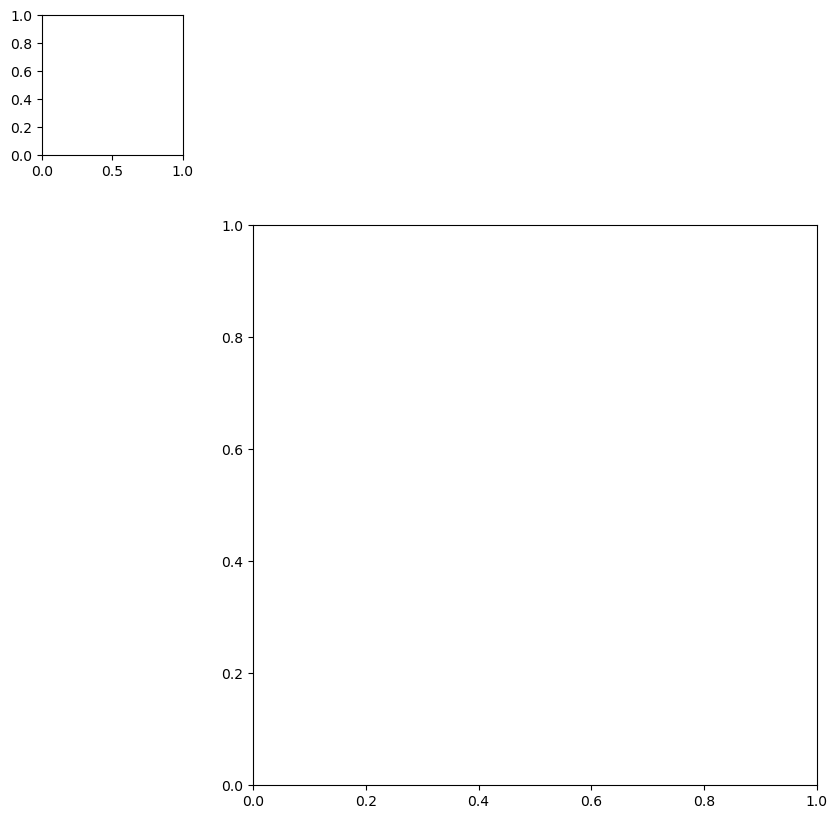

In [11]:
# just like characterize_network, compare_structure function allows you to provide the list of chosen properties for analysis using the parameter selected_props

# my_properties = ['EntropyPKout', 'ClusteringCoefficient', 'OutDegree', 'Density', 'Regulators']
my_properties = ['Complex Feed-Forward Circuits', 'Feed-Forward Circuits', '3-Feedback Loops']
# ERROR
compare_structure(networks, workers=2, association_metric=spearmanr, selected_props= my_properties);


[compare_structure] [WARNING] [Getting optimal number of workers based on available memory and inputed networks sizes...]


  0%|          | 0/15 [00:00<?, ?it/s]


[run_parallel] [WARNING] [Finilized: SF_1]


  7%|▋         | 1/15 [00:03<00:54,  3.88s/it]


[run_parallel] [WARNING] [Finilized: SF_2]

[run_parallel] [WARNING] [Finilized: SF_0]

[run_parallel] [WARNING] [Finilized: SF_4]


...

  0%|          | 0/5 [00:00<?, ?it/s]


[run_parallel] [WARNING] [Finilized: SF_7]


 20%|██        | 1/5 [00:02<00:09,  2.35s/it]


[run_parallel] [WARNING] [Finilized: SF_8]

[run_parallel] [WARNING] [Finilized: SF_5]

[run_parallel] [WARNING] [Finilized: SF_6]

[run_parallel] [WARNING] [Finilized: SF_9]


100%|██████████| 5/5 [00:02<00:00,  1.83it/s]


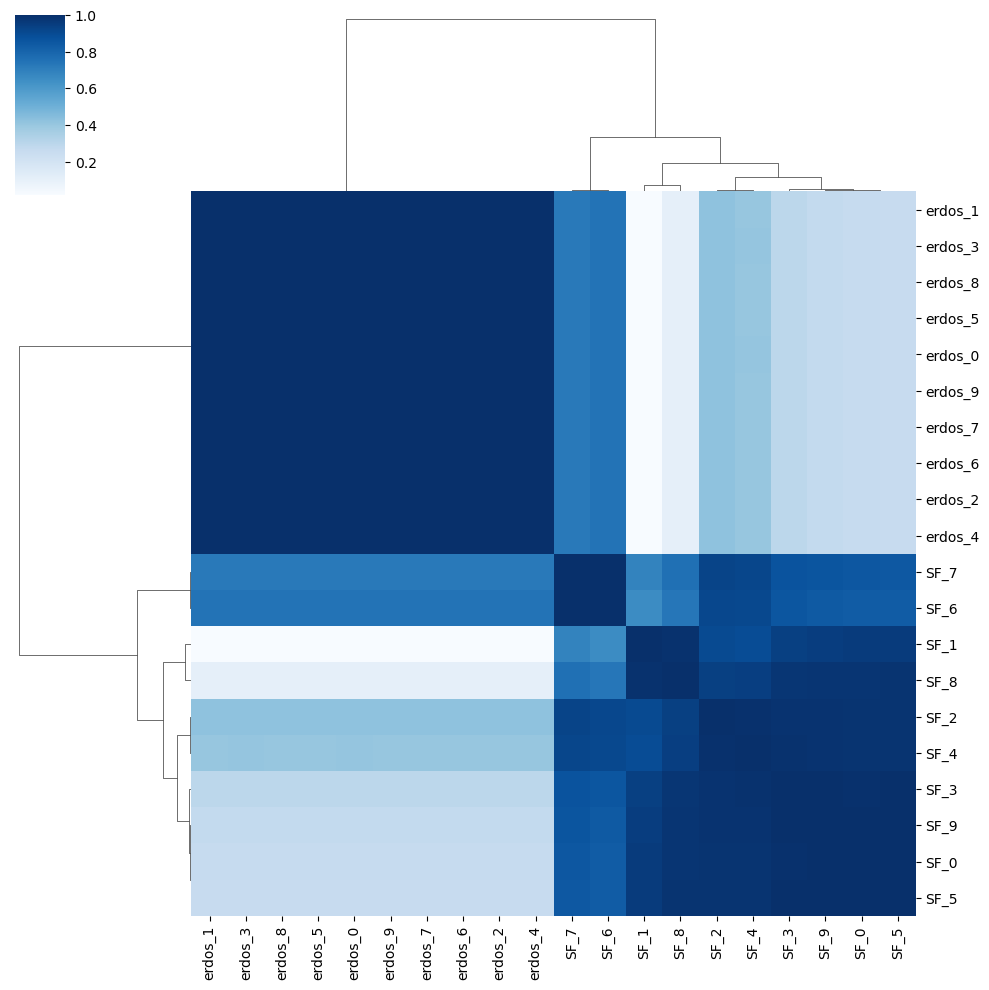

In [12]:
# Lets create a dict with 10 random networks to see the power of compare_structure

erdos_nets = {f'erdos_{i}': nx.fast_gnp_random_graph(100, 0.1, directed=True) for i in range(10)}
sf_nets = {f'SF_{i}': nx.DiGraph(nx.scale_free_graph(100)) for i in range(10)}

name_nets = {**erdos_nets, **sf_nets}

compare_structure(name_nets);

  0%|          | 0/2 [00:00<?, ?it/s]


[run_parallel] [WARNING] [Finilized: my_network_H]


 50%|█████     | 1/2 [00:02<00:02,  2.08s/it]


[run_parallel] [WARNING] [Finilized: my_network_G]


100%|██████████| 2/2 [00:02<00:00,  1.38s/it]


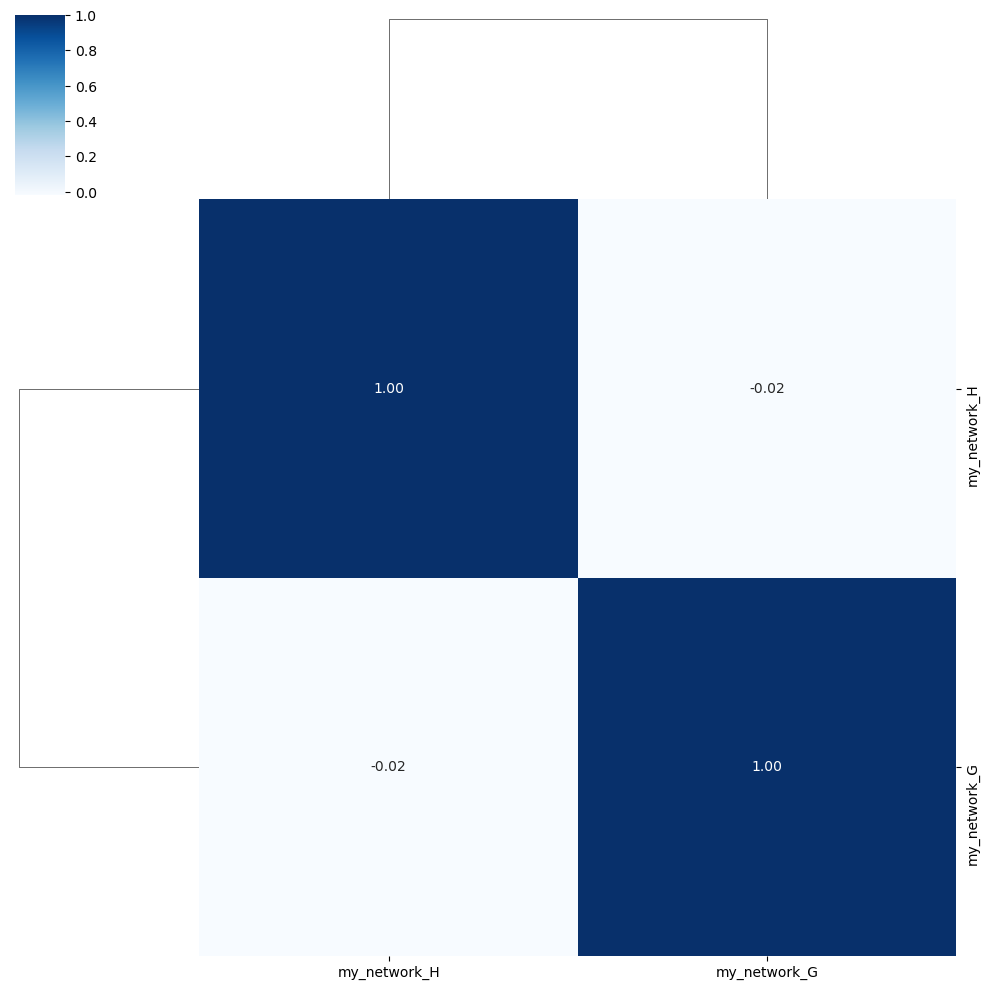

In [13]:
# Netective is also capable to compare a directed network with an undirected one
# A subset of properties they share is selected for analysis
# Biological normalization not recommended for this type of comparison

# Let's create a random UNDIRECTED network.
G = nx.erdos_renyi_graph(100, 0.3, directed=False)
# Let's create a second network to compare to the first one. Notice this is a directed network
H = nx.path_graph(50, create_using=nx.DiGraph)

networks = {"my_network_G": G, "my_network_H": H}
compare_structure(networks, norm='network', workers='auto');

<br>

### **Submodule `structure`** 🕸️📐

In [14]:
from netective.structure.structure import Structure

In [15]:
# The object Structure allows you to observe a graph constantly.

G = nx.erdos_renyi_graph(100, 0.2, directed=True)
s = Structure(G)
s.get_props()

({'0a8ee3db': {'Giant Component Size': 100,
   'Average Local Efficiency': 0.6723924323266331,
   'Average Shortest Path Length': 1.6488888888888888,
   'Center': 100,
   'Diameter': 2,
   'Global Efficiency': 0.6755555555555556,
   'Periphery': 100,
   'Radius': 2,
   'Complex Feed-Forward Circuits': 456,
   'Feed-Forward Circuits': 3701,
   '3-Feedback Loops': 2304,
   'Entropy of Degree Distribution': 3.8710914087320316,
   'Max Degree': 44,
   'Number of Edges': 1738,
   'Number of Nodes': 100,
   'Undirected Gini Index': 0.06391829689298045,
   'Undirected Self-Loops': 0,
   'Density': 0.1924,
   'Entropy of Out-Degree Distribution': 3.9513684459196035,
   'Gini Index': 0.12364864864864822,
   'Max In-Dregree': 26,
   'Max Out-Degree': 32,
   'Non-Leaf Nodes': 100,
   'Number of Arcs': 1924,
   'Self-Loops': 0,
   'Undirected Density': 0.1738}},
 {'0a8ee3db': {'Average Degree for Nearest Neighbors': array([35.30769231, 35.08823529, 35.60606061, 35.72222222, 34.12121212,
          

In [16]:
# if the graphs has not changed, it returned the curret props dict
s.get_props()

({'0a8ee3db': {'Giant Component Size': 100,
   'Average Local Efficiency': 0.6723924323266331,
   'Average Shortest Path Length': 1.6488888888888888,
   'Center': 100,
   'Diameter': 2,
   'Global Efficiency': 0.6755555555555556,
   'Periphery': 100,
   'Radius': 2,
   'Complex Feed-Forward Circuits': 456,
   'Feed-Forward Circuits': 3701,
   '3-Feedback Loops': 2304,
   'Entropy of Degree Distribution': 3.8710914087320316,
   'Max Degree': 44,
   'Number of Edges': 1738,
   'Number of Nodes': 100,
   'Undirected Gini Index': 0.06391829689298045,
   'Undirected Self-Loops': 0,
   'Density': 0.1924,
   'Entropy of Out-Degree Distribution': 3.9513684459196035,
   'Gini Index': 0.12364864864864822,
   'Max In-Dregree': 26,
   'Max Out-Degree': 32,
   'Non-Leaf Nodes': 100,
   'Number of Arcs': 1924,
   'Self-Loops': 0,
   'Undirected Density': 0.1738}},
 {'0a8ee3db': {'Average Degree for Nearest Neighbors': array([35.30769231, 35.08823529, 35.60606061, 35.72222222, 34.12121212,
          

In [17]:
# but recalculates the props if the graph changes without creating a new instance of the class.
G.add_edge("A", "B")
s.get_props()

({'0a8ee3db': {'Giant Component Size': 100,
   'Average Local Efficiency': 0.6723924323266331,
   'Average Shortest Path Length': 1.6488888888888888,
   'Center': 100,
   'Diameter': 2,
   'Global Efficiency': 0.6755555555555556,
   'Periphery': 100,
   'Radius': 2,
   'Complex Feed-Forward Circuits': 456,
   'Feed-Forward Circuits': 3701,
   '3-Feedback Loops': 2304,
   'Entropy of Degree Distribution': 3.9344206546747373,
   'Max Degree': 44,
   'Number of Edges': 1739,
   'Number of Nodes': 102,
   'Undirected Gini Index': 0.08166176188704366,
   'Undirected Self-Loops': 0,
   'Density': 0.1924,
   'Entropy of Out-Degree Distribution': 4.032731475446867,
   'Gini Index': 0.14025464731347081,
   'Max In-Dregree': 26,
   'Max Out-Degree': 32,
   'Non-Leaf Nodes': 101,
   'Number of Arcs': 1925,
   'Self-Loops': 0,
   'Undirected Density': 0.1738}},
 {'0a8ee3db': {'Average Degree for Nearest Neighbors': array([35.30769231, 35.08823529, 35.60606061, 35.72222222, 34.12121212,
          3

In [18]:
s.norm = "network"
s.get_props()

({'0a8ee3db': {'Giant Component Size': 0.9803921568627451,
   'Average Local Efficiency': 0.6723924323266331,
   'Average Shortest Path Length': 0.016655443322109987,
   'Center': 1.0,
   'Diameter': 0.020202020202020204,
   'Global Efficiency': 0.6755555555555556,
   'Periphery': 1.0,
   'Radius': 0.020202020202020204,
   'Complex Feed-Forward Circuits': 0.0026557949912638323,
   'Feed-Forward Circuits': 0.02155503785672685,
   '3-Feedback Loops': 0.01341875364006989,
   'Entropy of Degree Distribution': 0.589653754524024,
   'Max Degree': 0.43137254901960786,
   'Undirected Gini Index': 0.08166176188704366,
   'Undirected Self-Loops': 0.0,
   'Density': 0.1924,
   'Entropy of Out-Degree Distribution': 0.6043876504814244,
   'Gini Index': 0.14025464731347081,
   'Max In-Dregree': 0.2549019607843137,
   'Max Out-Degree': 0.3137254901960784,
   'Non-Leaf Nodes': 0.9901960784313726,
   'Self-Loops': 0.0,
   'Undirected Density': 0.1738}},
 {'0a8ee3db': {'Average Degree for Nearest Neighb

100%|██████████| 3/3 [00:01<00:00,  1.59it/s]


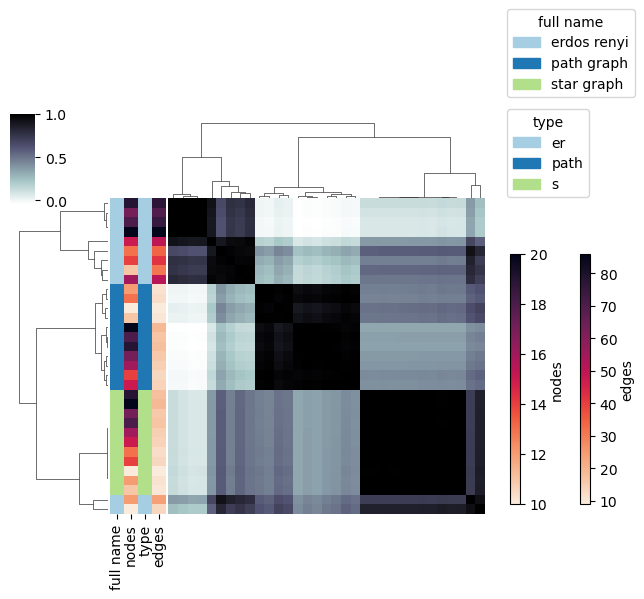

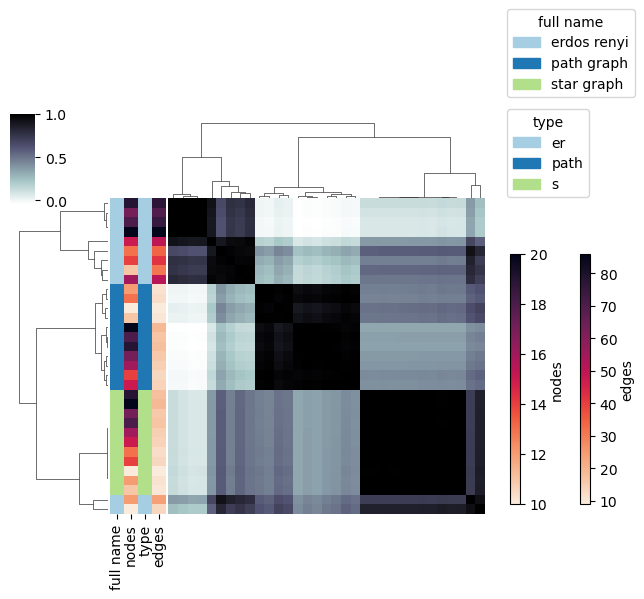

In [1]:
## add features

from netective import compare_structure
import networkx as nx
import pandas as pd

graphs = {}
features = pd.DataFrame(columns=['full name', 'nodes', 'type', 'edges'])

for n in range(10, 21):
    graphs[f'er_{n}'] = nx.erdos_renyi_graph(n, 0.5)
    graphs[f'p_{n}'] = nx.path_graph(n)
    graphs[f's_{n}'] = nx.star_graph(n-1)

    new_rows = pd.DataFrame({
        'full name': ['erdos renyi', 'path graph', 'star graph'],
        'nodes': [n, n, n],
        'type': ['er', 'path', 's'],
        'edges': [graphs[f'er_{n}'].number_of_edges(), graphs[f'p_{n}'].number_of_edges(), graphs[f's_{n}'].number_of_edges()]
    }, index=[f'er_{n}', f'p_{n}', f's_{n}'])

    features = pd.concat([features, new_rows])

data_type = {'nodes': 'numerical', 'type': 'categorical', 'edges': 'numerical', 'full name': 'categorical'}

compare_structure(graphs, n_jobs=8, features=features, data_type=data_type, verbose='CRITICAL');

## Classify networks

In [14]:
from netective.utils import parse_network

net_p = r"C:\Users\jmere\OneDrive\Escritorio\inferelator_gasch_GSE102475.txt"
G = parse_network(net_p, delimiter='\t', comments="#", directed=True, score=True)
G.number_of_edges(), G.number_of_nodes()

(619206, 3847)

In [13]:
[x for x in G.edges if 'Q0045' in x[0] or 'Q0045' in x[1]]

[('YBL052C', 'Q0045'),
 ('YBL103C', 'Q0045'),
 ('YBR049C', 'Q0045'),
 ('YBR066C', 'Q0045'),
 ('YBR083W', 'Q0045'),
 ('YBR103W', 'Q0045'),
 ('YBR150C', 'Q0045'),
 ('YBR245C', 'Q0045'),
 ('YBR275C', 'Q0045'),
 ('YCR065W', 'Q0045'),
 ('YCR084C', 'Q0045'),
 ('YDL020C', 'Q0045'),
 ('YDL056W', 'Q0045'),
 ('YDL070W', 'Q0045'),
 ('YDL106C', 'Q0045'),
 ('YDR049W', 'Q0045'),
 ('YDR073W', 'Q0045'),
 ('YDR081C', 'Q0045'),
 ('YDR096W', 'Q0045'),
 ('YDR146C', 'Q0045'),
 ('YDR169C', 'Q0045'),
 ('YDR176W', 'Q0045'),
 ('YDR181C', 'Q0045'),
 ('YDR207C', 'Q0045'),
 ('YDR266C', 'Q0045'),
 ('YDR310C', 'Q0045'),
 ('YDR392W', 'Q0045'),
 ('YDR421W', 'Q0045'),
 ('YDR423C', 'Q0045'),
 ('YDR443C', 'Q0045'),
 ('YDR463W', 'Q0045'),
 ('YDR477W', 'Q0045'),
 ('YEL009C', 'Q0045'),
 ('YEL056W', 'Q0045'),
 ('YER040W', 'Q0045'),
 ('YER068W', 'Q0045'),
 ('YER088C', 'Q0045'),
 ('YER111C', 'Q0045'),
 ('YER130C', 'Q0045'),
 ('YER161C', 'Q0045'),
 ('YER169W', 'Q0045'),
 ('YFL021W', 'Q0045'),
 ('YFL031W', 'Q0045'),
 ('YFL044C'

In [19]:
import networkx as nx
from netective import classify_networks

# Let's create a random network to characterize
networks = {
    'G': nx.erdos_renyi_graph(100, 0.3, directed=True),
    'H': nx.path_graph(50, create_using=nx.DiGraph),
    'F': nx.erdos_renyi_graph(50, 0.4, directed=True),
    'I': nx.erdos_renyi_graph(300, 0.2, directed=True),
    'J': nx.path_graph(100, create_using=nx.DiGraph),
}

classify_networks(networks)

  0%|          | 0/5 [00:00<?, ?it/s]


[run_parallel] [WARNING] [Finilized: H]


 20%|██        | 1/5 [00:02<00:09,  2.39s/it]


[run_parallel] [WARNING] [Finilized: J]

[run_parallel] [WARNING] [Finilized: F]


 60%|██████    | 3/5 [00:02<00:01,  1.43it/s]


[run_parallel] [WARNING] [Finilized: G]


 80%|████████  | 4/5 [00:03<00:00,  1.52it/s]


[run_parallel] [WARNING] [Finilized: I]


100%|██████████| 5/5 [00:11<00:00,  2.33s/it]


{1: ['H', 'J'], 2: ['F', 'G', 'I']}

### Structure advanced: Include your own properties

In [20]:
# To be able to include your own properties, you need to import the parent class first.
import networkx as nx
from netective.structure.properties import _Property, return_scalar, use_selfloops, check_raw_value, NormalizationError

# Then, you can create your own class inheriting from _Property.
# and implement the corresponding methods. You may want to use this class as a template.
# The decorators are used to define the required preprocessing for the input graph. Import them from netective.structure.properties too.
# Optionally, you may also want to import NormalizationError to raise an error if the property cannot be normalized.
@return_scalar
@use_selfloops
class MyProperty(_Property):
    """MyProperty class to use as a template for custom properties.

    Methods:
        compute: Compute the number of nodes of a graph.
        norm_biol: Not implemented.
        norm_network: Not implemented.
    """

    CLASS_NAME = "My Property" # Human readable name of the property.

    def __init__(self, G: nx.Graph):
        super().__init__(G)

    def compute(self) -> int:
        """Compute the number of nodes.

        Returns:
            int: always return 101.
        """
        return 101

    @check_raw_value
    def norm_biol(self) -> None:
        raise NormalizationError(
            "Not implemented for this example."
        )

    @check_raw_value
    def norm_network(self) -> float:
        raise NormalizationError(
            "Not implemented for this example."
        )

(<Figure size 200x810 with 1 Axes>, <Figure size 1200x750 with 11 Axes>)

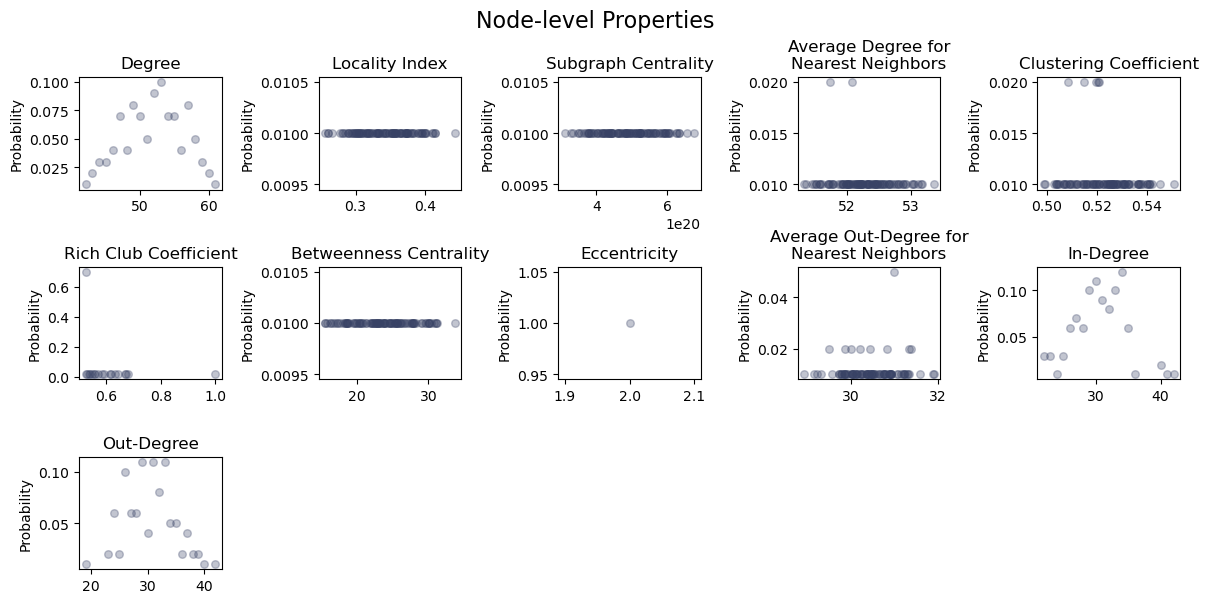

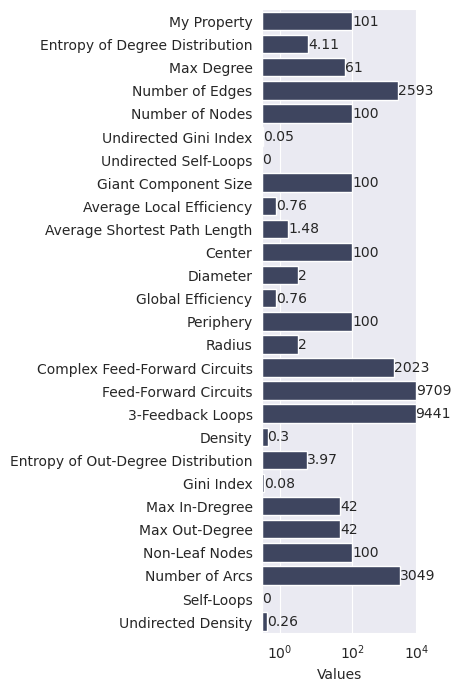

In [21]:
# Pass globals() as the include_env parameter to the function characterize_network.

from netective import characterize_network
G = nx.erdos_renyi_graph(100, 0.3, directed=True) # random network

characterize_network(G, "my_network", include_env=globals())

In [22]:
# This also works for compare_structure but you need to save the properties in a file first to import it
# We are using return_prop_dicts = True to get the properties dicts of the networks ans see our new property (My Property).
from netective import compare_structure

import inspect
import my_props # here my_props is in the same directory
my_props_env = dict(inspect.getmembers(my_props))
# Let's create two networks to compare
G = nx.erdos_renyi_graph(100, 0.3, directed=True)
H = nx.path_graph(50, create_using=nx.DiGraph)
networks = {"my_network_G": G, "my_network_H": H}
scalar, dist_moments = compare_structure(networks, return_prop_dicts=True, erdos_renyi=2, verbose='debug', include_env=my_props_env)


[INFO] MyProperty is a user-defined property.
[INFO] Properties used for analysis (based on selected_props): 
[INFO] My Property
[INFO] Average Degree for Nearest Neighbors
[INFO] Average Local Efficiency
[INFO] Average Out-Degree for Nearest Neighbors
[INFO] Average Shortest Path Length
[INFO] Betweenness Centrality
[INFO] Center
[INFO] Clustering Coefficient
[INFO] Complex Feed-Forward Circuits
[INFO] Degree
[INFO] Density
[INFO] Diameter
[INFO] Eccentricity
[INFO] Entropy of Degree Distribution
[INFO] Entropy of Out-Degree Distribution
[INFO] Feed-Forward Circuits
[INFO] 3-Feedback Loops
[INFO] Giant Component Size
[INFO] Gini Index
[INFO] Global Efficiency
[INFO] In-Degree
[INFO] Locality Index
[INFO] Max Degree
[INFO] Max In-Dregree
[INFO] Max Out-Degree
[INFO] Non-Leaf Nodes
[INFO] Number of Arcs
[INFO] Number of Edges
[INFO] Number of Nodes
[INFO] Out-Degree
[INFO] Periphery
[INFO] Radius
[INFO] Rich Club Coefficient
[INFO] Self-Loops
[INFO] Subgraph Centrality
[INFO] Undirected

  0%|          | 0/2 [00:00<?, ?it/s]

[INFO] Running my_network_G...
[INFO] Running my_network_H...


In [ ]:
# Let's check for our new property
scalar['my_network_G']['My Property']

# Note: If this raises a KeyError, make sure your property is included in the analysis.
# Check the norm parameter in compare_structure. Remember that properties without the required normalization are excluded.

: 


[get_props] [WARNING] [The network or the normalization method has changed. Computing its properties...]


(<Figure size 200x780 with 1 Axes>, <Figure size 1200x750 with 11 Axes>)

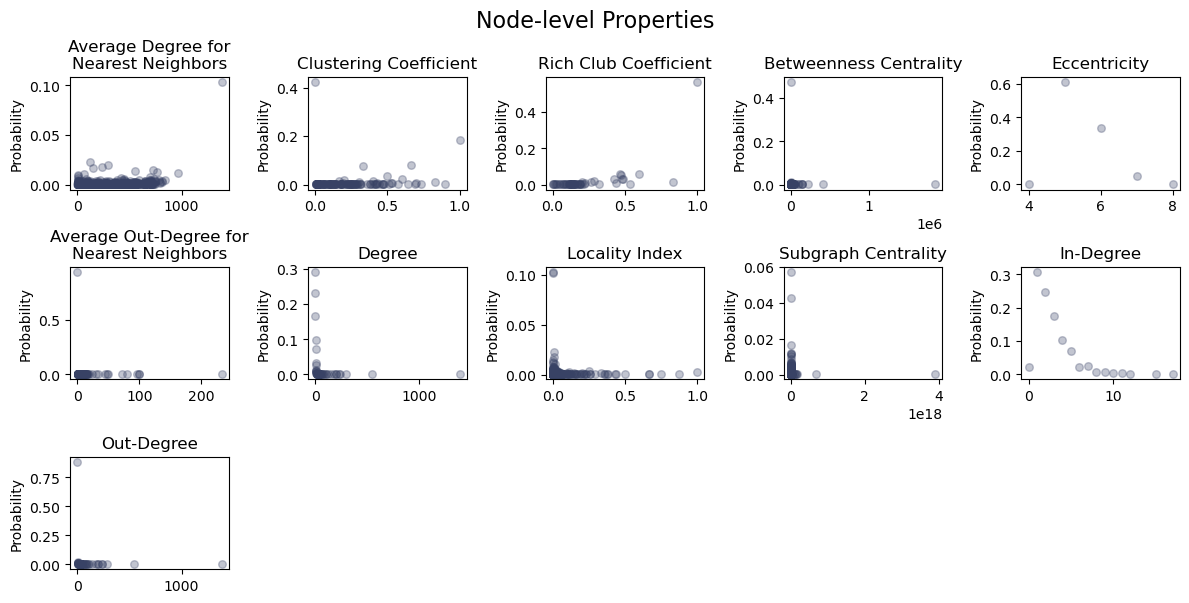

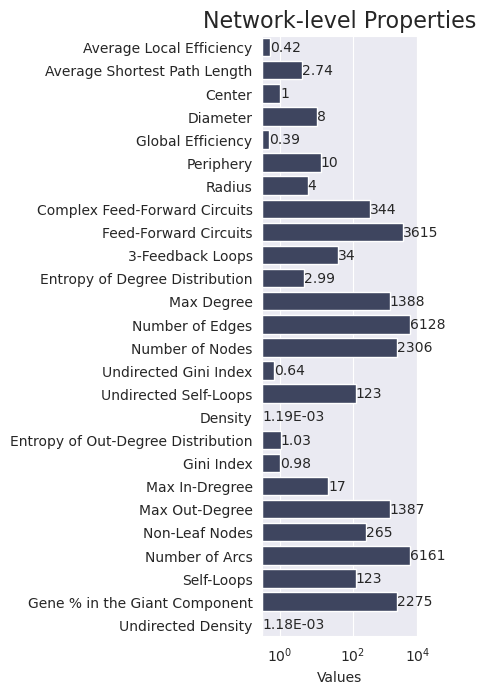

In [ ]:
from netective import characterize_network
from netective.utils import parse_network

from freyrelab.regnets import abasy
a = abasy.Abasy()
G = a.regnet('511145_v2022_sRDB22_eStrong')

characterize_network(G)

### **Submodule `stats`** 🕸️📐

This module allows you to evaluate an inferred network against a gold standard.

    Use the module-level function for a quick benchmarking


[__compute_roc_pr_datapoints] [WARNING] [The evaluation metrics have already been computed for this cutoff. Returning cached values.]

[__compute_roc_pr_datapoints] [WARNING] [The evaluation metrics have already been computed for this cutoff. Returning cached values.]

[__compute_roc_pr_datapoints] [WARNING] [The evaluation metrics have already been computed for this cutoff. Returning cached values.]

[__compute_roc_pr_datapoints] [WARNING] [The evaluation metrics have already been computed for this cutoff. Returning cached values.]

[__compute_roc_pr_datapoints] [WARNING] [The evaluation metrics have already been computed for this cutoff. Returning cached values.]

[__compute_roc_pr_datapoints] [WARNING] [The evaluation metrics have already been computed for this cutoff. Returning cached values.]

[__compute_roc_pr_datapoints] [WARNING] [The evaluation metrics have already been computed for this cutoff. Returning cached values.]

[__compute_roc_pr_datapoints] [WARNING] [The evaluatio

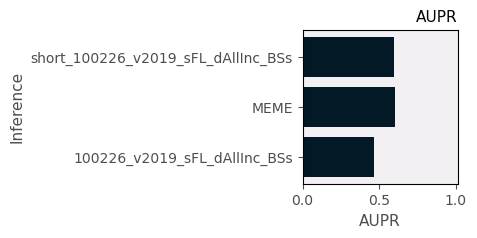

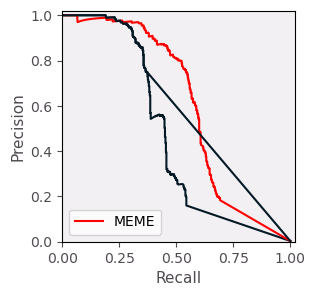

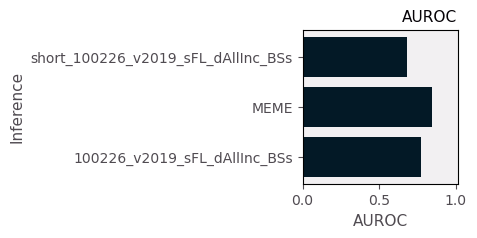

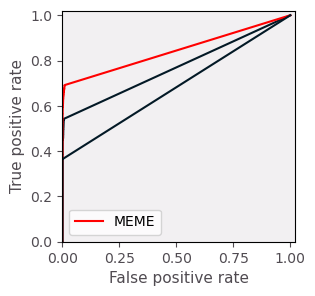

In [2]:
from netective import benchmarking

preds = 'assets/preds'
gs = 'assets/GS.txt'

fig_aupr, fig_pr_curves, fig_auroc, fig_roc_curves = benchmarking(preds, gs, greater_score_is_better=False, allow_self_loops=True, score=True, return_auc_dicts=False)

In [3]:
# save the fig 
import matplotlib.pyplot as plt
fig = fig_aupr.get_figure()
fig.savefig('assets/fig_aupr.png', bbox_inches='tight')

In [4]:
# use return_auc_dicts to keep the values
aupr, auroc = benchmarking(preds, gs, greater_score_is_better=False, allow_self_loops=True, score=True, return_auc_dicts=True)

print('AUPR')
for net, auc in aupr.items():
    print(f"{net}: {auc}")
print()
print('AUROC')
for net, auc in auroc.items():
    print(f"{net}: {auc}")


[__compute_roc_pr_datapoints] [WARNING] [The evaluation metrics have already been computed for this cutoff. Returning cached values.]

[__compute_roc_pr_datapoints] [WARNING] [The evaluation metrics have already been computed for this cutoff. Returning cached values.]

[__compute_roc_pr_datapoints] [WARNING] [The evaluation metrics have already been computed for this cutoff. Returning cached values.]


AUPR
100226_v2019_sFL_dAllInc_BSs: 0.46772006085898515
MEME: 0.6032994493883853
short_100226_v2019_sFL_dAllInc_BSs: 0.5950293039342102

AUROC
100226_v2019_sFL_dAllInc_BSs: 0.7692916019153007
MEME: 0.8437201083134056
short_100226_v2019_sFL_dAllInc_BSs: 0.6821591636021407


### using the module

In [5]:
# import the module
from netective.stats import stats

In [9]:
from netective.utils import parse_network
pred = 'assets\\short_100226_v2019_sFL_dAllInc_BSs.pred'
gs = 'assets\\short_GS.txt'


pred_graph = parse_network(pred, delimiter='\t', directed=True, score=True, use_position_as_score=False)

gold_standard_graph = parse_network(gs, delimiter='\t', directed=True)

bin_stats = stats.LinkEval(gold_standard_graph, pred_graph, greater_score_is_better=False, allow_self_loops=True, cutoff=False)
# cutoff is set to False to avoid trimming the prediction file

In [11]:
# get the area under the ROC curve
bin_stats.area_under_roc_curve()


[__compute_roc_pr_datapoints] [WARNING] [The evaluation metrics have already been computed for this cutoff. Returning cached values.]


0.5144585100062539

In [12]:
bin_stats.f1_score(), bin_stats.precision(), bin_stats.recall(), bin_stats.accuracy()

(0.05225225225225225, 0.2636363636363636, 0.029, 0.9989046230737193)


[__compute_roc_pr_datapoints] [WARNING] [The evaluation metrics have already been computed for this cutoff. Returning cached values.]


<Axes: title={'right': 'Optimal cutoff = 684.3333333333334'}, xlabel='Score', ylabel='Precision and recall'>

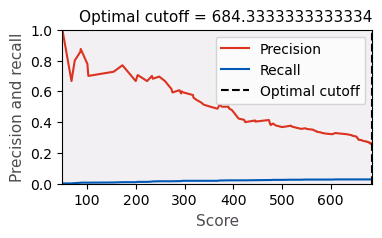

In [13]:
bin_stats.optimal_cutoff_plot()

In [14]:
# get the area under the precision-recall curve
bin_stats.area_under_precision_recall_curve()


[__compute_roc_pr_datapoints] [WARNING] [The evaluation metrics have already been computed for this cutoff. Returning cached values.]


0.14662813743217454


[__compute_roc_pr_datapoints] [WARNING] [The evaluation metrics have already been computed for this cutoff. Returning cached values.]


<Axes: title={'right': 'AUC-PR = 0.147'}, xlabel='Recall', ylabel='Precision'>

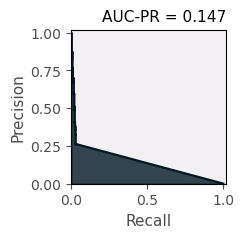

In [15]:
# plot the precision recall curve
bin_stats.plot_precision_recall_curve()


[__compute_roc_pr_datapoints] [WARNING] [The evaluation metrics have already been computed for this cutoff. Returning cached values.]


<Axes: title={'right': 'AUC-ROC = 0.514'}, xlabel='False positive rate', ylabel='True positive rate'>

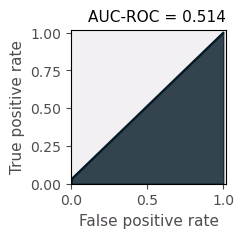

In [16]:
# plot the ROC curve
bin_stats.plot_roc_curve()

The computations and plots generated above, use the cutoff provided at the instatiation of the LinkEval class.

If you want to change the cutoff value, you can do so by changing the cutoff attribute of the class and then calling the plot functions again.

<Axes: title={'right': 'AUC-PR = 0.147'}, xlabel='Recall', ylabel='Precision'>

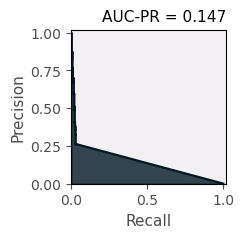

In [17]:
bin_stats.cutoff = 400
bin_stats.plot_precision_recall_curve()

You can also indicate the cutoff value when calling the method for a specific application:

<Axes: title={'right': 'AUC-PR = 0.441'}, xlabel='Recall', ylabel='Precision'>

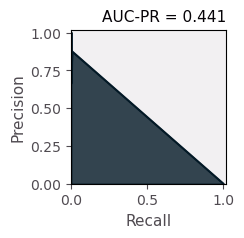

In [18]:
bin_stats.plot_precision_recall_curve(cutoff=100)

This won't change the associated cutoff value


[__compute_roc_pr_datapoints] [WARNING] [The evaluation metrics have already been computed for this cutoff. Returning cached values.]


<Axes: title={'right': 'AUC-PR = 0.147'}, xlabel='Recall', ylabel='Precision'>

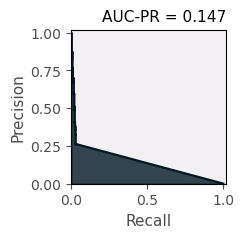

In [19]:
bin_stats.plot_precision_recall_curve()

In [1]:
from netective.stats import stats
from netective.utils import parse_network
pred = 'assets\\short_100226_v2019_sFL_dAllInc_BSs.pred'
gs = 'assets\\short_GS.txt'


pred_graph = parse_network(pred, delimiter='\t', directed=True, score=True, use_position_as_score=False)

gold_standard_graph = parse_network(gs, delimiter='\t', directed=True)

bin_stats = stats.LinkEval(gold_standard_graph, pred_graph, greater_score_is_better=False, allow_self_loops=True, cutoff=False)
# cutoff is set to False to avoid trimming the prediction file

pre, sen, fpr = bin_stats.coordinates()

(0.5144585100062539,
 0.14662813743217454,
 <Axes: title={'right': 'These curves'}, xlabel='False positive rate', ylabel='True positive rate'>,
 <Axes: title={'right': 'These curves'}, xlabel='Recall', ylabel='Precision'>)

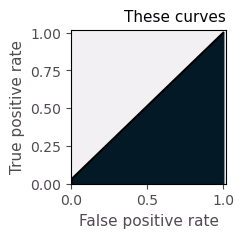

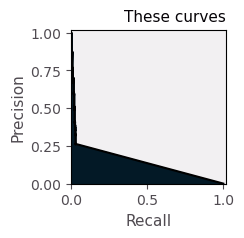

In [4]:
stats.LinkEval.curves_from_coordinates(pre, sen, fpr, title="These curves")

In [1]:
import os
from netective.stats.stats import Benchmark
from netective.utils import parse_network

preds = r'C:\Users\jmere\Dropbox (FreyreLab)\netective\netective_old_code\Applications\bs_coli'
gs = r"C:\Users\jmere\Dropbox (FreyreLab)\netective\netective_old_code\Applications\GS_bs.txt"

preds = {os.path.basename(f).split('.')[0]: parse_network(os.path.join(preds,f), delimiter='\t', directed=True, score=True, use_position_as_score=False) for f in os.listdir(preds)}
gold_standard_graph = parse_network(gs, delimiter='\t', directed=True, score=False, use_position_as_score=False)
foo = Benchmark(gold_standard_graph, preds, greater_score_is_better=False, allow_self_loops=True)

In [2]:
foo.sumarize()


[__compute_roc_pr_datapoints] [WARNING] [The evaluation metrics have already been computed for this cutoff. Returning cached values.]


1472 4038070 29810 2972



[__compute_roc_pr_datapoints] [WARNING] [The evaluation metrics have already been computed for this cutoff. Returning cached values.]


1308 4043746 24134 3136



[__compute_roc_pr_datapoints] [WARNING] [The evaluation metrics have already been computed for this cutoff. Returning cached values.]


...


[__compute_roc_pr_datapoints] [WARNING] [The evaluation metrics have already been computed for this cutoff. Returning cached values.]


1500 4033178 34702 2944



[__compute_roc_pr_datapoints] [WARNING] [The evaluation metrics have already been computed for this cutoff. Returning cached values.]

[__compute_roc_pr_datapoints] [WARNING] [The evaluation metrics have already been computed for this cutoff. Returning cached values.]


321 4064694 3186 4123
632 4055648 12232 3812


,AUPR,AUROC,F1 score,MCC,Optimal cutoff
Biopropector,0.060596,0.662588,0.082405,0.122488,0.000009
BoBro,0.096955,0.644646,0.087533,0.120844,0.000004
Community,0.206149,0.751886,0.033346,0.090584,18260.428571
GLAM2,0.151399,0.668555,0.059597,0.103298,0.000001
MDscan,0.048285,0.658620,0.067876,0.108339,0.000006
MEME,0.153693,0.665558,0.073808,0.115724,0.000001
RSATdyad,0.052213,0.535731,0.080745,0.080420,0.000085
Weeder,0.044396,0.569712,0.073030,0.081905,0.000022


In [2]:
pre, sen, fpr = foo.coordinates()['MEME']

(0.6655580949035639,
 0.15369329912750815,
 <Axes: title={'right': 'These curves'}, xlabel='False positive rate', ylabel='True positive rate'>,
 <Axes: title={'right': 'These curves'}, xlabel='Recall', ylabel='Precision'>)

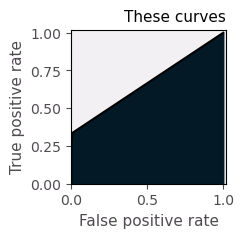

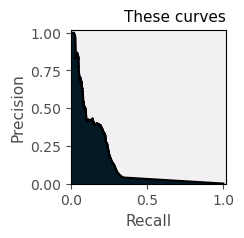

In [5]:
from netective.stats import stats

stats.LinkEval.curves_from_coordinates(pre, sen, fpr, title="These curves")